# Corpus EDA

What kind of dataset is this RAG system actually retrieving from?

The promoted workspace contains `501` documents and `18,734` normalized knowledge blocks. If those blocks are mostly structured telecom facts rather than generic prose, the system should benefit from lexical row keys, country metadata, and sender-type tags even when embeddings are available.

This notebook profiles corpus shape, metadata coverage, tag vocabulary, and data-quality signals to explain why retrieval is strong overall but citation and synthesis still fail in specific segments.

In [1]:
import json
import statistics
from collections import Counter
from pathlib import Path

ROOT = Path('..') if Path('../data/work/blocks.json').exists() else Path('.')
TABLE_DIR = ROOT / 'reports/tables'
TABLE_DIR.mkdir(parents=True, exist_ok=True)

blocks = json.loads((ROOT / 'data/work/blocks.json').read_text(encoding='utf-8'))
documents = json.loads((ROOT / 'data/work/documents.json').read_text(encoding='utf-8'))
manifest = json.loads((ROOT / 'data/work/manifest.json').read_text(encoding='utf-8'))

len(documents), len(blocks), manifest.get('embedding_model')


(501, 18734, 'BAAI/bge-small-en-v1.5')

## Corpus Shape

Hypothesis: `table_fact` and `structured_fact` blocks will dominate the corpus because telecom regulation data is mostly row-keyed country metadata. If true, exact lexical and metadata-aware retrieval should remain important even with semantic embeddings.

In [2]:
block_type_counts = Counter(block.get('block_type') or 'unknown' for block in blocks)
quality_counts = Counter(block.get('quality_status') or 'unknown' for block in blocks)
content_type_counts = Counter(document.get('content_type') or 'unknown' for document in documents)
answer_signal_counts = Counter(block.get('answer_signal') or 'unknown' for block in blocks)
row_key_values = [(block.get('metadata') or {}).get('row_key') for block in blocks]
row_key_counts = Counter(str(value).strip() for value in row_key_values if str(value or '').strip())
text_lengths = [len(block.get('text') or '') for block in blocks]
hypothetical_counts = [len(block.get('hypothetical_questions') or []) for block in blocks]

row_key_total_by_type = Counter()
row_key_missing_by_type = Counter()
for block, value in zip(blocks, row_key_values):
    block_type = block.get('block_type') or 'unknown'
    row_key_total_by_type[block_type] += 1
    if not str(value or '').strip():
        row_key_missing_by_type[block_type] += 1

row_key_coverage = []
for block_type, total in row_key_total_by_type.most_common():
    missing = row_key_missing_by_type[block_type]
    with_row_key = total - missing
    row_key_coverage.append({
        'block_type': block_type,
        'blocks': total,
        'with_row_key': with_row_key,
        'missing_row_key': missing,
        'coverage_rate': round(with_row_key / total, 4) if total else 0.0,
    })

coverage = {
    'summary_blocks': sum(1 for block in blocks if block.get('summary')),
    'country_or_iso_blocks': sum(1 for block in blocks if block.get('country') or block.get('iso_code')),
    'regulation_topic_blocks': sum(1 for block in blocks if block.get('regulation_topics')),
    'sender_type_blocks': sum(1 for block in blocks if block.get('sender_types')),
    'hypothetical_question_blocks': sum(1 for count in hypothetical_counts if count > 0),
    'row_key_blocks': sum(row_key_counts.values()),
    'missing_row_key_blocks': len(blocks) - sum(row_key_counts.values()),
}

print('Documents:', len(documents))
print('Blocks:', len(blocks))
print('Content types:', dict(content_type_counts))
print('Block types:', dict(block_type_counts))
print('Quality:', dict(quality_counts))
print('Coverage:', coverage)
print('Row-key coverage by block type:', row_key_coverage)
print('Text length median/mean/p90/max:', statistics.median(text_lengths), round(statistics.mean(text_lengths), 2), sorted(text_lengths)[int(.9*(len(text_lengths)-1))], max(text_lengths))
print('Hypothetical question blocks:', coverage['hypothetical_question_blocks'])


Documents: 501
Blocks: 18734
Content types: {'markdown': 277, 'json': 224}
Block types: {'table_fact': 9465, 'policy_rule': 1134, 'structured_fact': 6252, 'narrative': 1661, 'list_item': 210, 'faq': 12}
Quality: {'LOW_QUALITY': 1255, 'ok': 17479}
Coverage: {'summary_blocks': 0, 'country_or_iso_blocks': 17650, 'regulation_topic_blocks': 4642, 'sender_type_blocks': 9658, 'hypothetical_question_blocks': 229, 'row_key_blocks': 16513, 'missing_row_key_blocks': 2221}
Row-key coverage by block type: [{'block_type': 'table_fact', 'blocks': 9465, 'with_row_key': 9465, 'missing_row_key': 0, 'coverage_rate': 1.0}, {'block_type': 'structured_fact', 'blocks': 6252, 'with_row_key': 6252, 'missing_row_key': 0, 'coverage_rate': 1.0}, {'block_type': 'narrative', 'blocks': 1661, 'with_row_key': 0, 'missing_row_key': 1661, 'coverage_rate': 0.0}, {'block_type': 'policy_rule', 'blocks': 1134, 'with_row_key': 796, 'missing_row_key': 338, 'coverage_rate': 0.7019}, {'block_type': 'list_item', 'blocks': 210, '

**Finding:** table and structured facts dominate the corpus, while long narrative/policy blocks form the harder citation cases. This supports hybrid retrieval: exact row labels and metadata matter as much as semantic similarity.

## Vocabulary and Data Quality Signals

Hypothesis: sender-ID, provisioning, country, and compliance terms will dominate the vocabulary, while duplicated tag variants create avoidable retrieval and analysis noise. If variants are common, tag normalization is a real DS/data-quality task, not cosmetic cleanup.

In [3]:
raw_tags = []
for block in blocks:
    for key in ['sender_types', 'regulation_topics', 'canonical_terms', 'channels']:
        raw_tags.extend(str(value).strip().lower() for value in (block.get(key) or []) if str(value).strip())
    metadata = block.get('metadata') or {}
    for key in ['tag_attribute', 'tag_table_type', 'row_key']:
        value = str(metadata.get(key) or '').strip().lower()
        if value:
            raw_tags.append(value)

tag_counts = Counter(raw_tags)
for tag, count in tag_counts.most_common(25):
    print(f'{count:5} {tag}')

print('\nVariant families worth normalizing:')
for pattern in ['alphanumeric', 'sender', 'two-way', 'mms', 'sms', 'registration']:
    hits = [(tag, count) for tag, count in tag_counts.most_common() if pattern in tag][:8]
    print(pattern, hits)

 6782 short code
 6588 long code
 5492 key_value
 3880 pre-registration
 3707 alphanumeric sender id
 3625 sms
 2529 matrix
 2459 provisioning time
 1100 dialing code
  900 operator network capability
  900 twilio supported
  898 sender id preserved
  786 ucs-2 support
  666 locale name
  666 iso code
  666 region
  666 mobile country code
  666 two-way sms supported
  666 twilio mms support
  666 sending sms to landline numbers
  666 compliance considerations
  663 twilio concatenated message support
  654 message length
  648 use case restrictions
  642 number portability available

Variant families worth normalizing:
alphanumeric [('alphanumeric sender id', 3707), ('alphanumeric sender id (business names like "bird" or "netflix" that send one-way messages)', 221)]
sender [('alphanumeric sender id', 3707), ('sender id preserved', 898), ('sender availability', 436), ('sender provisioning', 436), ('alphanumeric sender id (business names like "bird" or "netflix" that send one-way messag

## Corpus Composition Charts

Hypothesis: structured/table-derived block types, country metadata, and sender-type vocabulary should dominate the corpus. If long narrative and policy blocks are a minority but disproportionately long, they are plausible citation-risk candidates.

Wrote summary to ../reports/tables/corpus_eda_summary.json
Wrote row-key coverage to ../reports/tables/row_key_coverage_by_block_type.csv


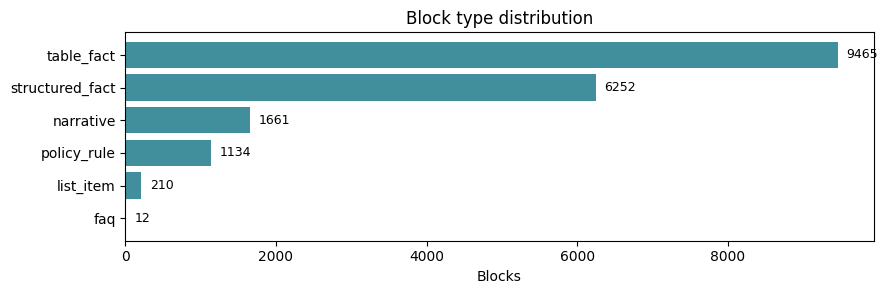

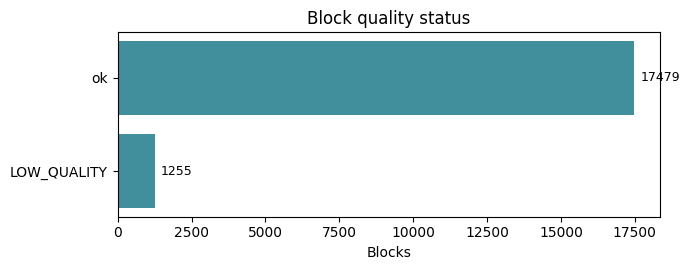

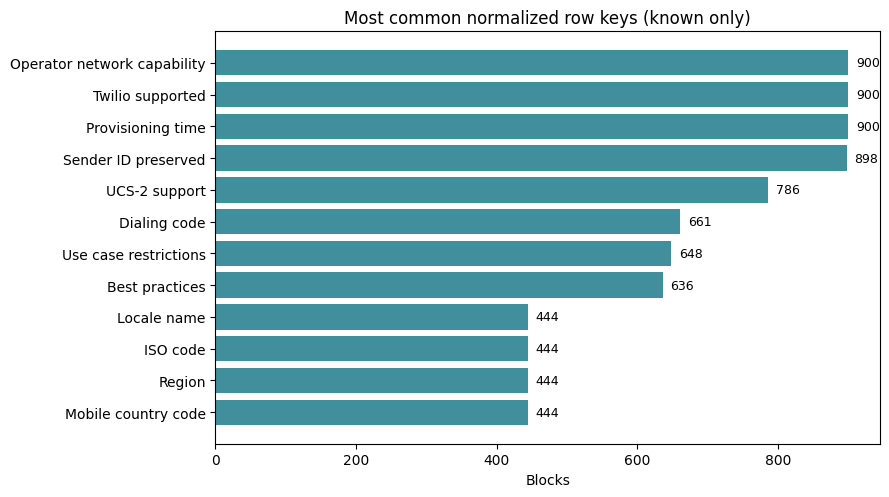

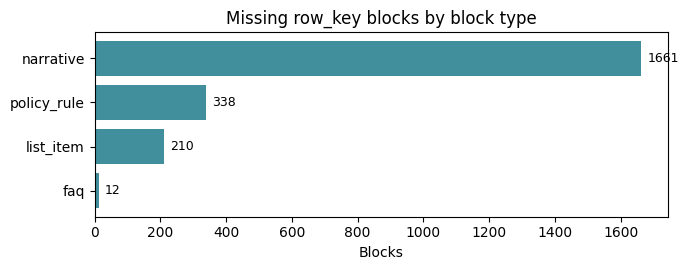

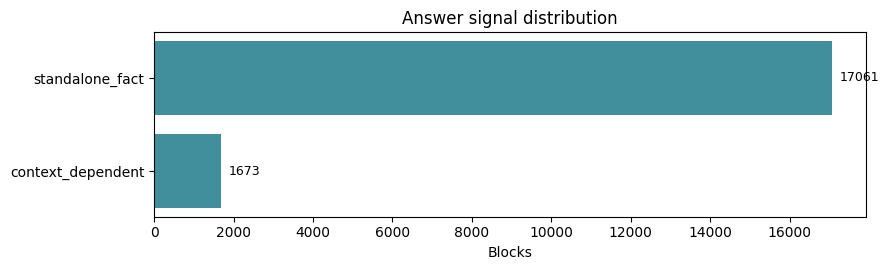

In [4]:
import csv
import matplotlib.pyplot as plt


def plot_count_bar(title, counter, limit=12, width=9):
    rows = counter.most_common(limit)
    labels = [label for label, _ in rows]
    values = [value for _, value in rows]
    fig_height = max(2.8, 1.0 + 0.34 * len(rows))
    fig, ax = plt.subplots(figsize=(width, fig_height))
    y_pos = range(len(rows))
    ax.barh(y_pos, values, color='#277f8e', alpha=0.88)
    ax.set_yticks(y_pos, labels)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('Blocks')
    max_value = max(values) if values else 1
    for y, value in zip(y_pos, values):
        ax.text(value + max_value * 0.012, y, f'{value}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

missing_row_key_counts = Counter({
    row['block_type']: row['missing_row_key']
    for row in row_key_coverage
    if row['missing_row_key']
})

summary = {
    'documents': len(documents),
    'blocks': len(blocks),
    'block_type_counts': dict(block_type_counts),
    'quality_counts': dict(quality_counts),
    'content_type_counts': dict(content_type_counts),
    'answer_signal_counts': dict(answer_signal_counts),
    'row_key_counts_known_only': dict(row_key_counts),
    'row_key_coverage_by_block_type': row_key_coverage,
    'coverage': coverage,
    'text_length': {'min': min(text_lengths), 'median': statistics.median(text_lengths), 'mean': round(statistics.mean(text_lengths), 2), 'p90': sorted(text_lengths)[int(.9*(len(text_lengths)-1))], 'max': max(text_lengths)},
    'hypothetical_questions': {'min': min(hypothetical_counts), 'median': statistics.median(hypothetical_counts), 'mean': round(statistics.mean(hypothetical_counts), 2), 'max': max(hypothetical_counts)},
    'top_tags': tag_counts.most_common(30),
}
(TABLE_DIR / 'corpus_eda_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')

coverage_path = TABLE_DIR / 'row_key_coverage_by_block_type.csv'
with coverage_path.open('w', newline='', encoding='utf-8') as fh:
    writer = csv.DictWriter(fh, fieldnames=['block_type', 'blocks', 'with_row_key', 'missing_row_key', 'coverage_rate'])
    writer.writeheader()
    writer.writerows(row_key_coverage)

print(f'Wrote summary to {TABLE_DIR / "corpus_eda_summary.json"}')
print(f'Wrote row-key coverage to {coverage_path}')
plot_count_bar('Block type distribution', block_type_counts)
plot_count_bar('Block quality status', quality_counts, limit=len(quality_counts), width=7)
plot_count_bar('Most common normalized row keys (known only)', row_key_counts)
plot_count_bar('Missing row_key blocks by block type', missing_row_key_counts, limit=len(missing_row_key_counts), width=7)
plot_count_bar('Answer signal distribution', answer_signal_counts)


Finding: the previous `unknown = 2,221` bar was not a normalized row key; it was the count of blocks without a `metadata.row_key`. That is expected for `narrative`, `list_item`, and `faq` blocks, and the diagnostic table shows `table_fact` and `structured_fact` have 100% row-key coverage. The fix is to exclude missing row keys from the top-key chart and track missing coverage separately by `block_type`.


## Information Density by Block Type

Hypothesis: `policy_rule` and `narrative` blocks will be much longer than table-derived facts. If long blocks also sit in documents with citation or synthesis failures, they are plausible RAG-risk candidates because answer generation has to select a small claim from a broad passage.


{'block_type': 'policy_rule', 'blocks': 1134, 'median_length': 233.0, 'mean_length': 326.97, 'p90_length': 642, 'p95_length': 944, 'max_length': 3680}
{'block_type': 'structured_fact', 'blocks': 6252, 'median_length': 171.0, 'mean_length': 223.45, 'p90_length': 409, 'p95_length': 524, 'max_length': 3874}
{'block_type': 'table_fact', 'blocks': 9465, 'median_length': 75, 'mean_length': 124.5, 'p90_length': 308, 'p95_length': 350, 'max_length': 1692}
{'block_type': 'list_item', 'blocks': 210, 'median_length': 54.0, 'mean_length': 56.63, 'p90_length': 92, 'p95_length': 100, 'max_length': 180}
{'block_type': 'narrative', 'blocks': 1661, 'median_length': 57, 'mean_length': 50.93, 'p90_length': 74, 'p95_length': 83, 'max_length': 252}
{'block_type': 'faq', 'blocks': 12, 'median_length': 29.5, 'mean_length': 32.08, 'p90_length': 37, 'p95_length': 44, 'max_length': 45}


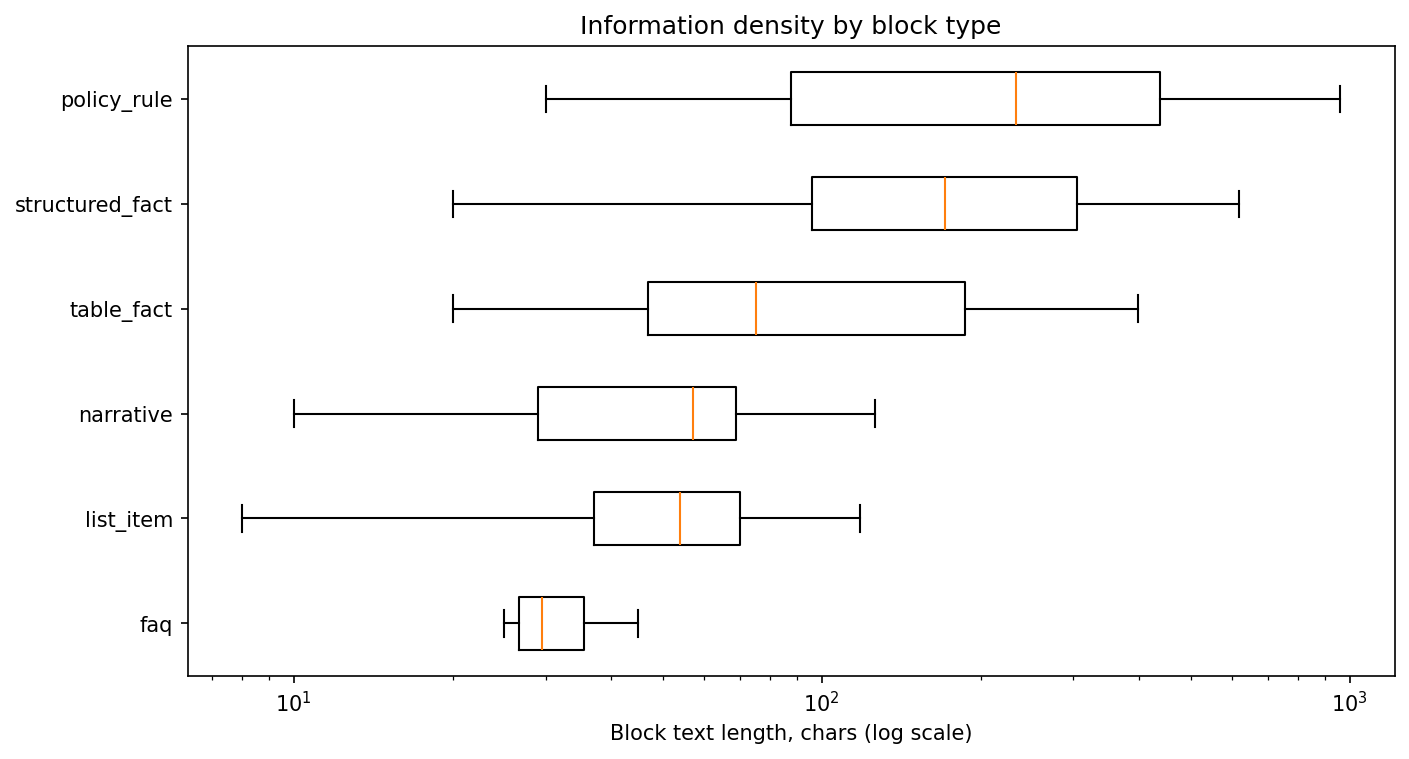

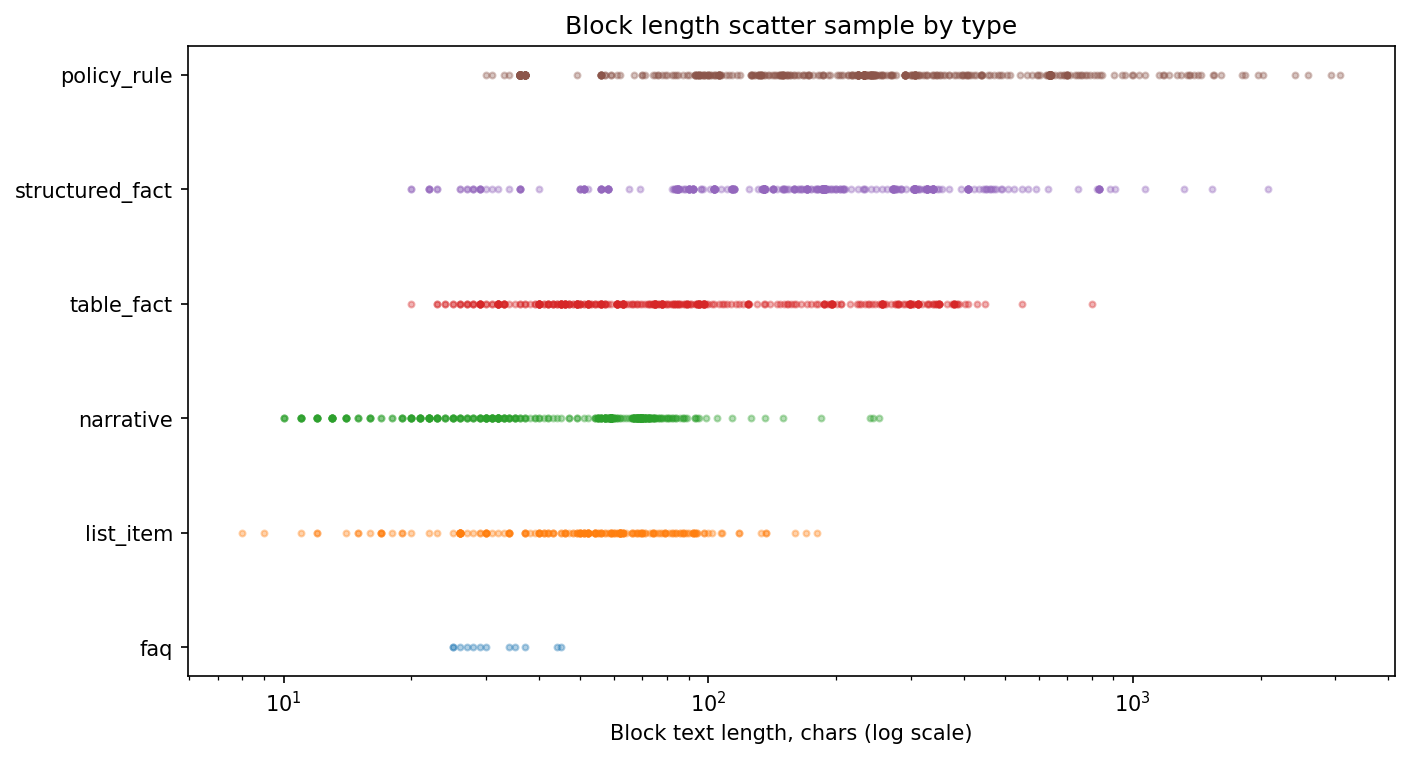

In [5]:
from collections import defaultdict
from io import BytesIO
from IPython.display import Image, display


def display_png(fig):
    buffer = BytesIO()
    fig.savefig(buffer, format='png', dpi=150, bbox_inches='tight')
    plt.close(fig)
    display(Image(data=buffer.getvalue()))


lengths_by_type = defaultdict(list)
for block in blocks:
    lengths_by_type[block.get('block_type') or 'unknown'].append(len(block.get('text') or ''))

length_summary = []
for block_type, values in sorted(lengths_by_type.items()):
    sorted_values = sorted(values)
    p90 = sorted_values[int(0.90 * (len(sorted_values) - 1))]
    p95 = sorted_values[int(0.95 * (len(sorted_values) - 1))]
    length_summary.append({
        'block_type': block_type,
        'blocks': len(values),
        'median_length': round(statistics.median(values), 2),
        'mean_length': round(statistics.mean(values), 2),
        'p90_length': p90,
        'p95_length': p95,
        'max_length': max(values),
    })

for row in sorted(length_summary, key=lambda item: item['p95_length'], reverse=True):
    print(row)

labels = [row['block_type'] for row in sorted(length_summary, key=lambda item: item['median_length'])]
plot_values = [lengths_by_type[label] for label in labels]
fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.boxplot(plot_values, tick_labels=labels, vert=False, showfliers=False)
ax.set_xscale('log')
ax.set_xlabel('Block text length, chars (log scale)')
ax.set_title('Information density by block type')
plt.tight_layout()
display_png(fig)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
for index, label in enumerate(labels):
    values = sorted(lengths_by_type[label])
    sample = values[::max(1, len(values) // 400)]
    y = [index] * len(sample)
    ax.scatter(sample, y, s=8, alpha=0.35)
ax.set_yticks(range(len(labels)), labels)
ax.set_xscale('log')
ax.set_xlabel('Block text length, chars (log scale)')
ax.set_title('Block length scatter sample by type')
plt.tight_layout()
display_png(fig)


**Finding:** `policy_rule` blocks have the highest median and p95 text length, while structured/table p95 outliers can also be very long when they preserve large regulatory table cells. The next cell turns those outliers into a reviewable table instead of treating text length as a vague visual observation.


## Long-Block Risk Table

Hypothesis: the highest-risk long blocks will be p95 outliers within their own `block_type`, especially `policy_rule` and `narrative` blocks that belong to documents with citation or answer-synthesis failures. This does not prove causality, but it creates a concrete review queue.


In [6]:
evaluation_path = ROOT / 'data/work/evaluation/latest-evaluation.json'
evaluation_summary = json.loads(evaluation_path.read_text(encoding='utf-8')) if evaluation_path.exists() else {'results': []}

doc_failure_counts = Counter()
doc_citation_failures = Counter()
doc_synthesis_failures = Counter()
for row in evaluation_summary.get('results', []):
    if row.get('answer_correct') or row.get('should_refuse'):
        continue
    related_docs = set(row.get('expected_document_ids') or []) | set(row.get('retrieved_document_ids') or [])
    for document_id in related_docs:
        doc_failure_counts[document_id] += 1
        if row.get('failure_stage') == 'citation':
            doc_citation_failures[document_id] += 1
        if row.get('failure_stage') == 'answer_synthesis':
            doc_synthesis_failures[document_id] += 1

p90_by_type = {row['block_type']: row['p90_length'] for row in length_summary}
p95_by_type = {row['block_type']: row['p95_length'] for row in length_summary}

def block_tags(block):
    metadata = block.get('metadata') or {}
    values = []
    for key in ['sender_types', 'regulation_topics', 'canonical_terms', 'channels']:
        values.extend(str(value) for value in (block.get(key) or []) if str(value).strip())
    for key in ['row_key', 'tag_attribute', 'tag_table_type']:
        value = str(metadata.get(key) or '').strip()
        if value:
            values.append(value)
    return '; '.join(dict.fromkeys(values))

def preview(text, max_chars=220):
    cleaned = ' '.join(str(text or '').split())
    return cleaned if len(cleaned) <= max_chars else cleaned[:max_chars - 3].rstrip() + '...'

risk_rows = []
for block in blocks:
    block_type = block.get('block_type') or 'unknown'
    length = len(block.get('text') or '')
    p90 = p90_by_type.get(block_type, 0)
    p95 = p95_by_type.get(block_type, 0)
    is_p95 = length >= p95 if p95 else False
    is_long_risk_type = block_type in {'policy_rule', 'narrative'} and length >= p90
    if not (is_p95 or is_long_risk_type):
        continue
    document_id = block.get('document_id') or ''
    risk_rows.append({
        'document_id': document_id,
        'block_id': block.get('block_id') or '',
        'block_type': block_type,
        'text_length': length,
        'block_type_p90': p90,
        'block_type_p95': p95,
        'is_p95_outlier': is_p95,
        'long_policy_or_narrative': is_long_risk_type,
        'document_failure_count': doc_failure_counts[document_id],
        'document_citation_failures': doc_citation_failures[document_id],
        'document_synthesis_failures': doc_synthesis_failures[document_id],
        'quality_status': block.get('quality_status') or '',
        'tags': block_tags(block),
        'text_preview': preview(block.get('text') or ''),
    })

risk_rows.sort(key=lambda row: (row['document_failure_count'], row['text_length']), reverse=True)
risk_path = TABLE_DIR / 'long_block_risk.csv'
with risk_path.open('w', newline='', encoding='utf-8') as fh:
    fieldnames = [
        'document_id', 'block_id', 'block_type', 'text_length', 'block_type_p90', 'block_type_p95',
        'is_p95_outlier', 'long_policy_or_narrative', 'document_failure_count',
        'document_citation_failures', 'document_synthesis_failures', 'quality_status', 'tags', 'text_preview'
    ]
    writer = csv.DictWriter(fh, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(risk_rows)

print(f'Wrote {len(risk_rows)} long-block risk rows to {risk_path}')
for row in risk_rows[:10]:
    print(row['document_id'], row['block_type'], row['text_length'], 'failures=', row['document_failure_count'], row['text_preview'][:100])


Wrote 1123 long-block risk rows to ../reports/tables/long_block_risk.csv
united_states_us table_fact 1692 failures= 9 Regarding Phone Numbers & Sender ID: Long codes and short codes for Use case restrictions: the Long 
united_states_us structured_fact 1640 failures= 9 - Use case restrictions: Long code domestic=Loan Advertisements - Third Party Lenders “Get rich quic
united_states_us structured_fact 1586 failures= 9 - Compliance considerations: Description=Twilio strongly encourages customers to review proposed use
united_states_us policy_rule 1392 failures= 9 For Guidelines, the Compliance considerations is: Twilio’s customers, including their end users and 
united_states_us policy_rule 835 failures= 9 For united-states, the Country restrictions is: Prohibited content - SPAM - Fraudulent or misleading
united_states_us table_fact 800 failures= 9 Regarding Phone Numbers & Sender ID: Toll Free for Use case restrictions: the Toll Free is High-Risk
united_states_us structured_fact 743 fail

**Finding:** long blocks are now a concrete review queue in `reports/tables/long_block_risk.csv`. The table distinguishes within-type p95 outliers from long policy passages and adds document-level failure counts so reviewers can prioritize blocks that are both dense and associated with observed benchmark errors.


## Reviewable Tag-Normalization Candidates

Hypothesis: tag variants are mostly formatting differences (`sender-id`, `sender id`, `sender_id`) and near-duplicates around sender, registration, two-way, and MMS concepts. A reviewable candidate table should reduce vocabulary noise without silently changing production metadata.


In [8]:
import re
from difflib import SequenceMatcher


def normalize_tag(value):
    cleaned = str(value).lower()
    cleaned = cleaned.replace('&', ' and ')
    cleaned = re.sub(r'[^a-z0-9]+', ' ', cleaned)
    cleaned = re.sub(r'smses', 'sms', cleaned)
    cleaned = re.sub(r'ids', 'id', cleaned)
    cleaned = re.sub(r'codes', 'code', cleaned)
    cleaned = re.sub(r'numbers', 'number', cleaned)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned


def token_set(value):
    return set(normalize_tag(value).split())

unique_tags = sorted(tag_counts)
parent = {tag: tag for tag in unique_tags}

def find(tag):
    while parent[tag] != tag:
        parent[tag] = parent[parent[tag]]
        tag = parent[tag]
    return tag

def union(left, right):
    root_left = find(left)
    root_right = find(right)
    if root_left != root_right:
        parent[root_right] = root_left

normalized_buckets = defaultdict(list)
for tag in unique_tags:
    normalized_buckets[normalize_tag(tag)].append(tag)
for variants in normalized_buckets.values():
    for tag in variants[1:]:
        union(variants[0], tag)

candidate_tags = [tag for tag in unique_tags if tag_counts[tag] >= 2]
for index, left in enumerate(candidate_tags):
    left_norm = normalize_tag(left)
    left_tokens = token_set(left)
    if len(left_norm) < 4 or not left_tokens:
        continue
    for right in candidate_tags[index + 1:]:
        right_norm = normalize_tag(right)
        right_tokens = token_set(right)
        if len(right_norm) < 4 or not right_tokens:
            continue
        jaccard = len(left_tokens & right_tokens) / max(1, len(left_tokens | right_tokens))
        similarity = SequenceMatcher(None, left_norm, right_norm).ratio()
        if left_tokens == right_tokens or jaccard >= 0.82 or similarity >= 0.92:
            union(left, right)

groups = defaultdict(list)
for tag in unique_tags:
    groups[find(tag)].append(tag)

candidate_groups = []
for variants in groups.values():
    variants = sorted(variants, key=lambda tag: (-tag_counts[tag], tag))
    if len(variants) < 2:
        continue
    total_count = sum(tag_counts[tag] for tag in variants)
    if total_count < 5:
        continue
    canonical = normalize_tag(variants[0])
    candidate_groups.append({
        'canonical_suggestion': canonical,
        'variant_count': len(variants),
        'total_count': total_count,
        'variants': variants,
    })

candidate_groups.sort(key=lambda row: (row['variant_count'], row['total_count']), reverse=True)
rows = []
for group_id, group in enumerate(candidate_groups, start=1):
    for variant in group['variants']:
        rows.append({
            'group_id': group_id,
            'canonical_suggestion': group['canonical_suggestion'],
            'variant': variant,
            'variant_count': tag_counts[variant],
            'group_total_count': group['total_count'],
            'group_variant_count': group['variant_count'],
            'review_status': 'candidate',
        })

candidate_path = TABLE_DIR / 'tag_normalization_candidates.csv'
with candidate_path.open('w', newline='', encoding='utf-8') as fh:
    fieldnames = ['group_id', 'canonical_suggestion', 'variant', 'variant_count', 'group_total_count', 'group_variant_count', 'review_status']
    writer = csv.DictWriter(fh, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

summary_payload = {
    'unique_tags_before': len(unique_tags),
    'candidate_groups': len(candidate_groups),
    'candidate_variant_rows': len(rows),
    'proposed_unique_tags_after_review': len(unique_tags) - sum(group['variant_count'] - 1 for group in candidate_groups),
    'estimated_vocab_reduction': sum(group['variant_count'] - 1 for group in candidate_groups),
    'top_candidate_groups': [
        {
            'canonical_suggestion': group['canonical_suggestion'],
            'variant_count': group['variant_count'],
            'total_count': group['total_count'],
            'variants': group['variants'][:12],
        }
        for group in candidate_groups[:12]
    ],
}
summary_path = TABLE_DIR / 'tag_normalization_summary.json'
summary_path.write_text(json.dumps(summary_payload, indent=2), encoding='utf-8')

print(f'Wrote {len(rows)} candidate variant rows to {candidate_path}')
print(f'Wrote summary to {summary_path}')
print(summary_payload)
for group in candidate_groups[:8]:
    print(group['canonical_suggestion'], group['variant_count'], group['variants'][:8])


Wrote 4 candidate variant rows to ../reports/tables/tag_normalization_candidates.csv
Wrote summary to ../reports/tables/tag_normalization_summary.json
{'unique_tags_before': 758, 'candidate_groups': 2, 'candidate_variant_rows': 4, 'proposed_unique_tags_after_review': 756, 'estimated_vocab_reduction': 2, 'top_candidate_groups': [{'canonical_suggestion': 'sender id preserved', 'variant_count': 2, 'total_count': 900, 'variants': ['sender id preserved', 'senderid preserved']}, {'canonical_suggestion': 'content restriction', 'variant_count': 2, 'total_count': 19, 'variants': ['content_restriction', 'content restrictions']}]}
sender id preserved 2 ['sender id preserved', 'senderid preserved']
content restriction 2 ['content_restriction', 'content restrictions']


**Finding:** tag normalization is now reviewable rather than automatic. `reports/tables/tag_normalization_candidates.csv` proposes candidate groups with counts, while `reports/tables/tag_normalization_summary.json` estimates the vocabulary reduction if those groups are approved. This is intentionally a candidate list, not a silent production rewrite.


## Interpretation

Summary of findings: the corpus is not generic prose. It is a structured telecom regulation dataset with country metadata, row-key-heavy vocabulary, sparse generated-question coverage, and a minority of low-quality or long policy blocks that likely increase citation risk.

Next experiment: enrich the sparse `hypothetical_questions` coverage for high-error binary row keys, then rerun retrieval and failure analysis. If evidence hit improves but answer correctness does not, the next fix is answer templating rather than representation tuning.